In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\johnm\fingerprint-feature-analyzer


In [2]:
from processing.preprocessing import (
    load_image,
    convert_to_grayscale,
    normalize_image,
    denoise_image,
    enhance_contrast
)

print("Preprocessing functions loaded.")

Preprocessing functions loaded.


In [3]:
image_path = next(
    (PROJECT_ROOT / "data" / "raw" / "NISTDB4").rglob("*.png")
)

print("Selected image:", image_path)

Selected image: c:\Users\johnm\fingerprint-feature-analyzer\data\raw\NISTDB4\class1_Arc\class1_Arc_0001.png


In [4]:
image = load_image(image_path)

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Pixel range:", image.min(), "to", image.max())

Image shape: (512, 512)
Image dtype: uint8
Pixel range: 8 to 255


In [5]:
gray = convert_to_grayscale(image)
normalized = normalize_image(gray)
denoised = denoise_image(normalized)
enhanced = enhance_contrast(denoised)

print("Preprocessing complete.")
print("Enhanced shape:", enhanced.shape)
print("Enhanced dtype:", enhanced.dtype)

Preprocessing complete.
Enhanced shape: (512, 512)
Enhanced dtype: uint8


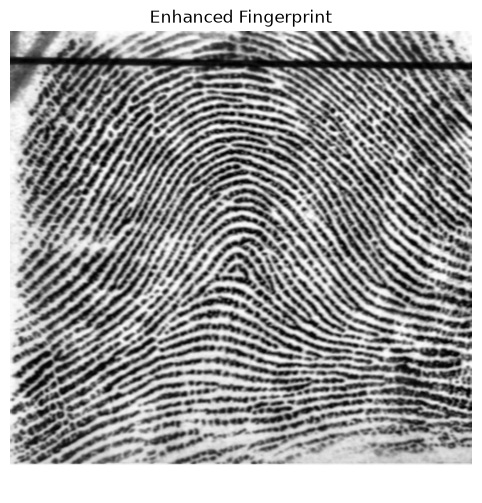

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(enhanced, cmap="gray")
plt.title("Enhanced Fingerprint")
plt.axis("off")
plt.show()

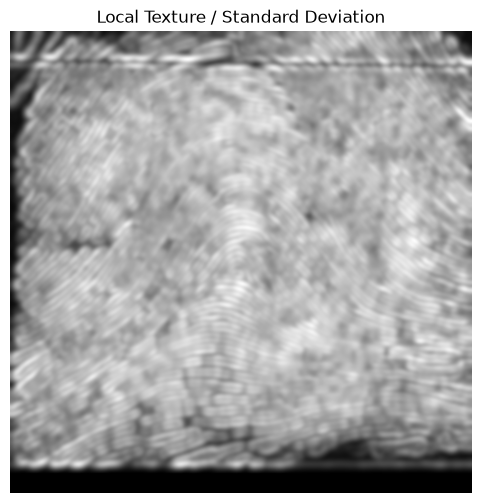

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_float = enhanced.astype(np.float32)

mean = cv2.GaussianBlur(image_float, (21, 21), 0)
mean_squared = cv2.GaussianBlur(image_float ** 2, (21, 21), 0)

local_variance = mean_squared - (mean ** 2)
local_variance = np.maximum(local_variance, 0)

local_std = np.sqrt(local_variance)

plt.figure(figsize=(7, 6))
plt.imshow(local_std, cmap="gray")
plt.title("Local Texture / Standard Deviation")
plt.axis("off")
plt.show()

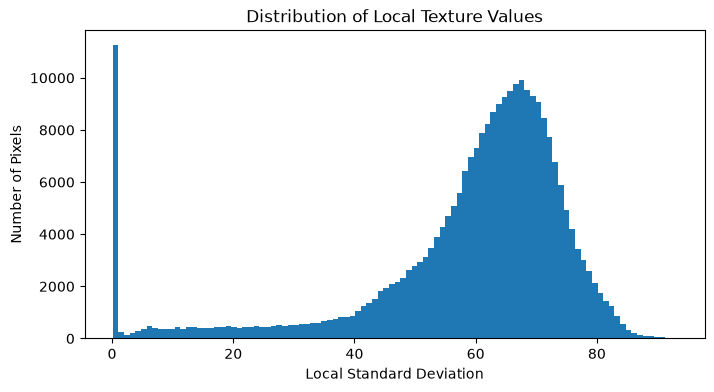

In [8]:
plt.figure(figsize=(8, 4))

plt.hist(local_std.ravel(), bins=100)

plt.xlabel("Local Standard Deviation")
plt.ylabel("Number of Pixels")
plt.title("Distribution of Local Texture Values")
plt.show()

Otsu threshold: 107.0


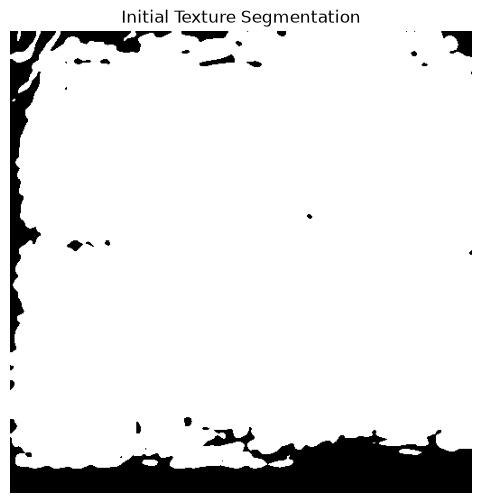

In [9]:
texture_uint8 = cv2.normalize(
    local_std,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

otsu_threshold, texture_mask = cv2.threshold(
    texture_uint8,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu threshold:", otsu_threshold)

plt.figure(figsize=(7, 6))
plt.imshow(texture_mask, cmap="gray")
plt.title("Initial Texture Segmentation")
plt.axis("off")
plt.show()

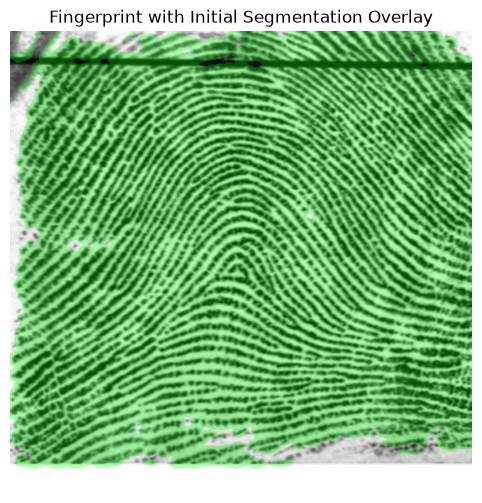

In [10]:
overlay = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)

overlay[texture_mask == 255] = (
    0.7 * overlay[texture_mask == 255]
    + 0.3 * np.array([0, 255, 0])
).astype(np.uint8)

plt.figure(figsize=(7, 6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Fingerprint with Initial Segmentation Overlay")
plt.axis("off")
plt.show()

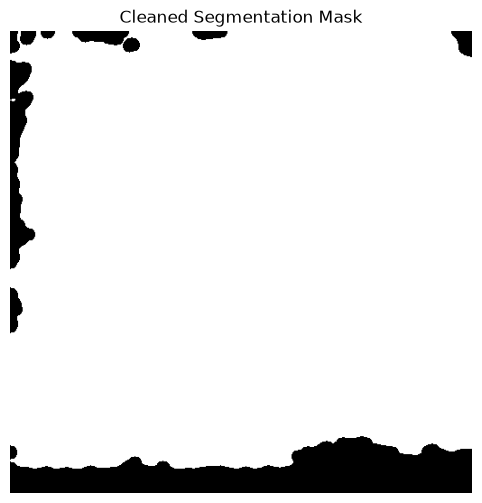

In [11]:
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (15, 15)
)

cleaned_mask = cv2.morphologyEx(
    texture_mask,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(7, 6))
plt.imshow(cleaned_mask, cmap="gray")
plt.title("Cleaned Segmentation Mask")
plt.axis("off")
plt.show()

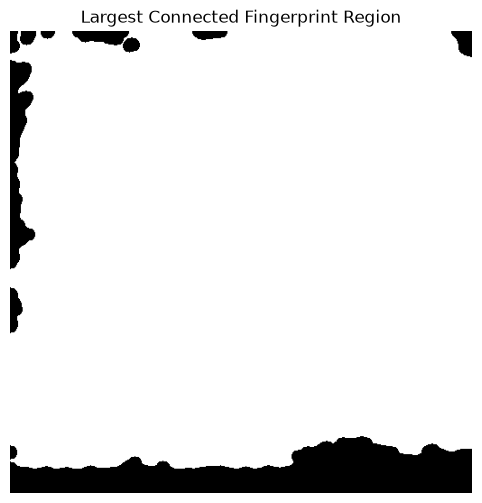

In [12]:
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
    cleaned_mask,
    connectivity=8
)

largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

largest_component = np.zeros_like(cleaned_mask)
largest_component[labels == largest_label] = 255

plt.figure(figsize=(7, 6))
plt.imshow(largest_component, cmap="gray")
plt.title("Largest Connected Fingerprint Region")
plt.axis("off")
plt.show()

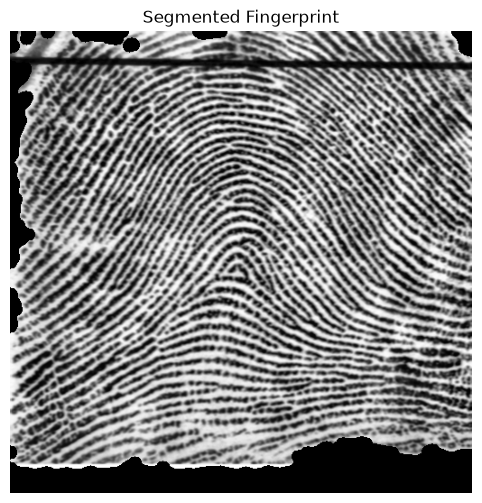

In [13]:
segmented_fingerprint = cv2.bitwise_and(
    enhanced,
    enhanced,
    mask=largest_component
)

plt.figure(figsize=(7, 6))
plt.imshow(segmented_fingerprint, cmap="gray")
plt.title("Segmented Fingerprint")
plt.axis("off")
plt.show()

In [14]:
foreground_pixels = np.count_nonzero(largest_component)
total_pixels = largest_component.size

foreground_percentage = (
    foreground_pixels / total_pixels
) * 100

print("Foreground pixels:", foreground_pixels)
print("Total pixels:", total_pixels)
print(f"Foreground coverage: {foreground_percentage:.2f}%")

Foreground pixels: 236112
Total pixels: 262144
Foreground coverage: 90.07%


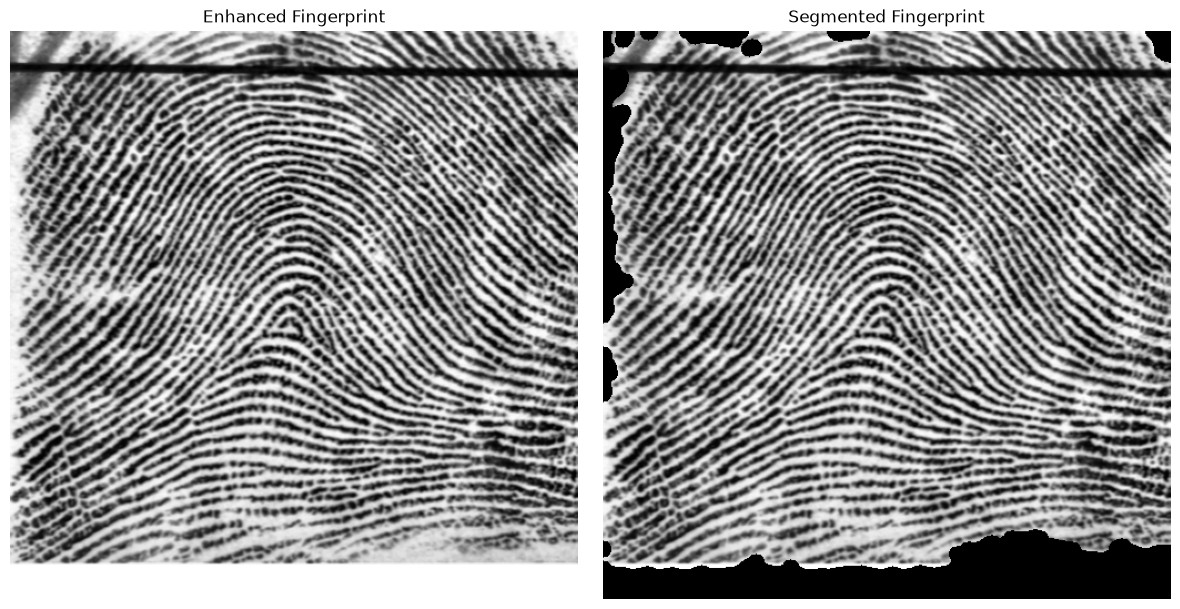

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(enhanced, cmap="gray")
axes[0].set_title("Enhanced Fingerprint")
axes[0].axis("off")

axes[1].imshow(segmented_fingerprint, cmap="gray")
axes[1].set_title("Segmented Fingerprint")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [16]:
segmentation_coverage = (
    np.count_nonzero(largest_component)
    / largest_component.size
) * 100

print("SEGMENTATION CHECKPOINT")
print("----------------------")
print(f"Image size: {enhanced.shape}")
print(f"Foreground coverage: {segmentation_coverage:.2f}%")
print("Segmentation status: Experimental pipeline validated")

SEGMENTATION CHECKPOINT
----------------------
Image size: (512, 512)
Foreground coverage: 90.07%
Segmentation status: Experimental pipeline validated
